<a href="https://colab.research.google.com/github/Shaileshsingh1442007/K-NN/blob/main/Lab11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Example 1: Simple k-NN on the Iris Dataset**

In [1]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier

# Load data
iris = load_iris()
X, y = iris.data, iris.target

# Train k-NN model with k=3
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, y)

# Predict a sample
print("Predicted class:", knn.predict([[5.1, 3.5, 1.4, 0.2]]))


Predicted class: [0]


# **Example 2: Train/Test Split and Accuracy Evaluation**

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict and evaluate
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0


# **Example 3: Find Optimal k using Cross-Validation**

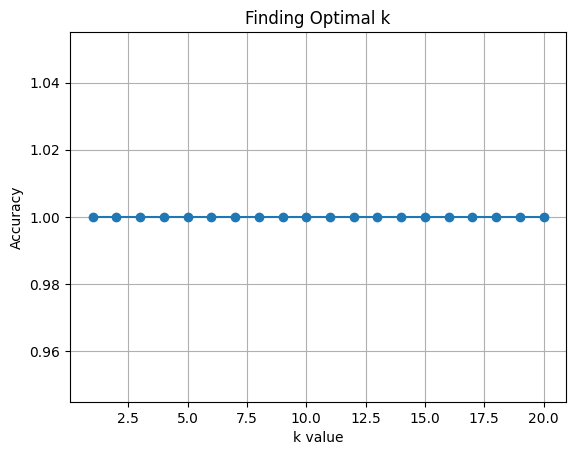

Optimal k: 1


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Try k values from 1 to 20
k_range = range(1, 21)
accuracies = []

for k in k_range:
   knn = KNeighborsClassifier(n_neighbors=k)
   knn.fit(X_train, y_train)
   score = knn.score(X_test, y_test)
   accuracies.append(score)

# Plot accuracy vs k
plt.plot(k_range, accuracies, marker='o')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.title('Finding Optimal k')
plt.grid(True)
plt.show()

# Print the best k
optimal_k = k_range[np.argmax(accuracies)]
print("Optimal k:", optimal_k)

# **Example 4: Use Pipeline with Standardization (Moderate Level)**


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create pipeline with scaling
pipeline = Pipeline([
   ('scaler', StandardScaler()),
   ('knn', KNeighborsClassifier(n_neighbors=optimal_k))
])

pipeline.fit(X_train, y_train)
print("Pipeline accuracy:", pipeline.score(X_test, y_test))


Pipeline accuracy: 0.9777777777777777


# **Example 5: k-NN on Breast Cancer Dataset with Confusion Matrix**

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict and evaluate
y_pred = knn.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[ 57   6]
 [  1 107]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.90      0.94        63
           1       0.95      0.99      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



# **Example 6: k-NN with GridSearchCV to Find Best k**


In [6]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {'n_neighbors': list(range(1, 21))}

# Use GridSearchCV
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best k:", grid.best_params_['n_neighbors'])
print("Best cross-validated score:", grid.best_score_)

Best k: 8
Best cross-validated score: 0.9169936708860759


# **Example 7: Visualizing Decision Boundaries (2D for Iris Dataset)**


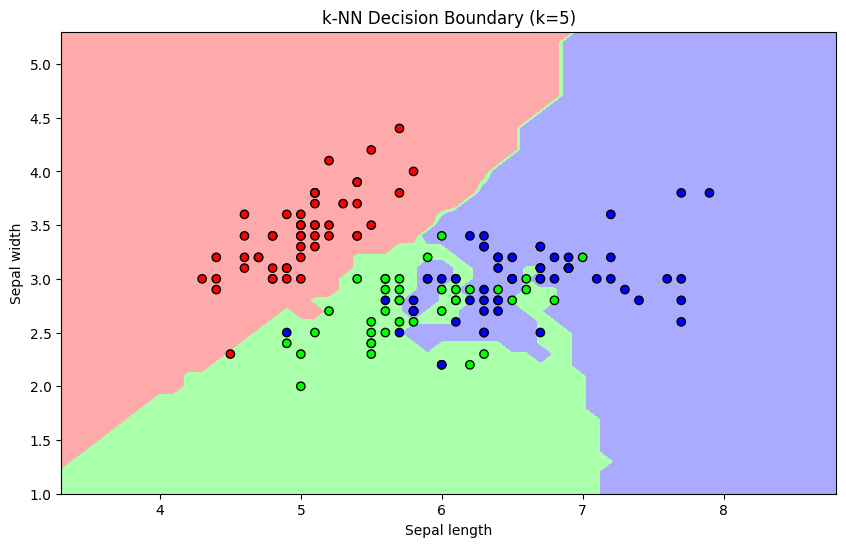

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Use only 2 features for 2D plot
X_plot = iris.data[:, :2]
y_plot = iris.target

# Train model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_plot, y_plot)

# Create mesh grid
x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                    np.arange(y_min, y_max, 0.1))

# Predict grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, edgecolor='k', cmap=ListedColormap(['#FF0000', '#00FF00', '#0000FF']))
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('k-NN Decision Boundary (k=5)')
plt.show()

# **Example 8: Normalize Data Manually before k-NN**


In [8]:
from sklearn.preprocessing import MinMaxScaler

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

print("Accuracy with normalized data:", knn.score(X_test, y_test))

Accuracy with normalized data: 0.9649122807017544
